# SVR - Support Vector Regression

## Synthetic Non-linear regression

### Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Import Scikit learn Modules

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import (
     SVR, LinearSVR
)
from sklearn.linear_model import (
     LinearRegression, Ridge, Lasso, ElasticNet
)
from sklearn.metrics import (
     mean_absolute_error, mean_squared_error, r2_score
)

### Create a non-linear Regression Data

In [5]:
np.random.seed(42)

x = np.sort(6 * np.random.rand(300, 1), axis=0)
y = np.sin(X).ravel() + 0.15 * np.random.randn(300)

### train and test split

In [8]:
X_train, X_test, y_train, y_test=train_test_split(
     x,y,
     test_size=0.25,
     random_state=42
)

### Evaluation Function

In [9]:
def evaluate_regression_model(name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    y_train_pred = model.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

    return {
        "model": name,
        "train_rmse": train_rmse,
        "test_mae": mean_absolute_error(y_test, y_pred),
        "test_rmse": rmse,
        "test_r2": r2_score(y_test, y_pred),
        "generalization_gap_rmse": rmse - train_rmse,
        "training_time_sec": train_time,
        "prediction_time_sec": pred_time
    }


### Define Models

In [10]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000))
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))
    ]),

    "Linear SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="linear", C=1.0, epsilon=0.1))
    ]),

    "LinearSVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42))
    ]),

    "Polynomial SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="poly", degree=3, C=10, epsilon=0.1, gamma="scale"))
    ]),

    "RBF SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale"))
    ])
}

### Train and Compare

In [12]:
import time
results = []

for name, model in models.items():
    result = evaluate_regression_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    results.append(result)

results_df = pd.DataFrame(results).sort_values(by="test_rmse")
print(results_df)

               model  train_rmse  test_mae  test_rmse   test_r2  \
7            RBF SVR    0.147953  0.120263   0.148263  0.962084   
0  Linear Regression    0.437451  0.401397   0.454763  0.643281   
3         ElasticNet    0.437452  0.401510   0.454763  0.643280   
2              Lasso    0.437452  0.401537   0.454764  0.643280   
1              Ridge    0.437460  0.401777   0.454770  0.643269   
4         Linear SVR    0.443348  0.400592   0.466527  0.624587   
5          LinearSVR    0.443520  0.400991   0.467079  0.623697   
6     Polynomial SVR    0.631203  0.588680   0.654767  0.260513   

   generalization_gap_rmse  training_time_sec  prediction_time_sec  
7                 0.000310           0.005457             0.001750  
0                 0.017312           0.009894             0.001251  
3                 0.017312           0.003901             0.000616  
2                 0.017311           0.003336             0.000629  
1                 0.017311           0.002659      

### Plot Prediction Curves

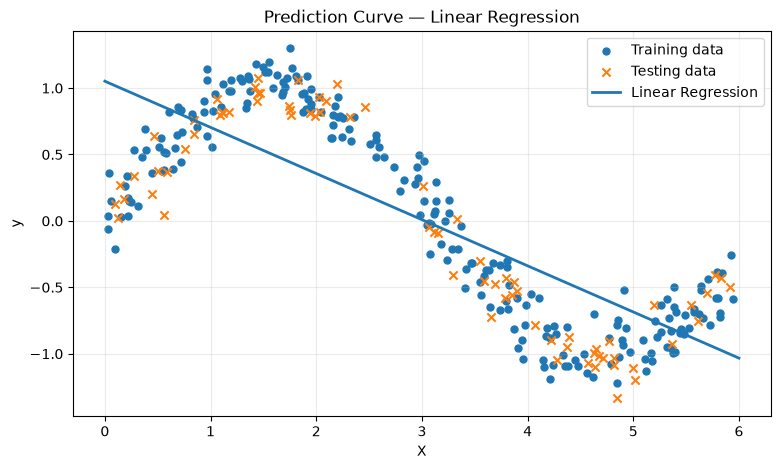

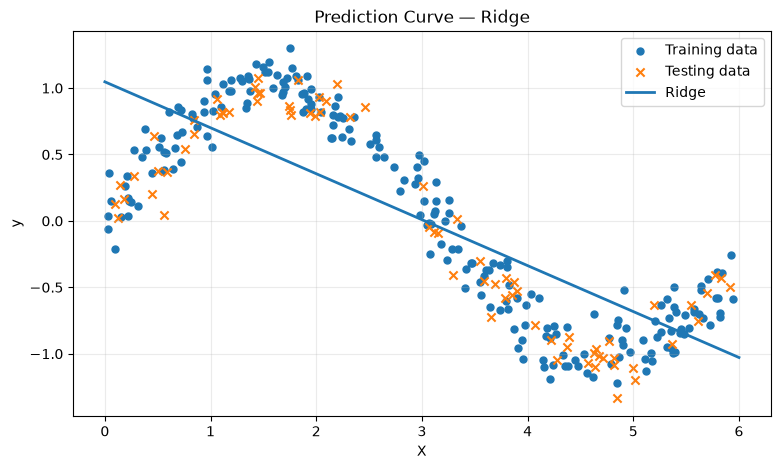

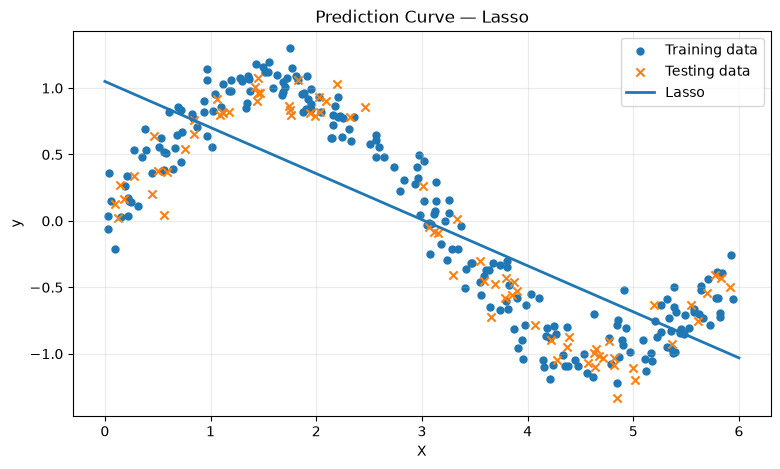

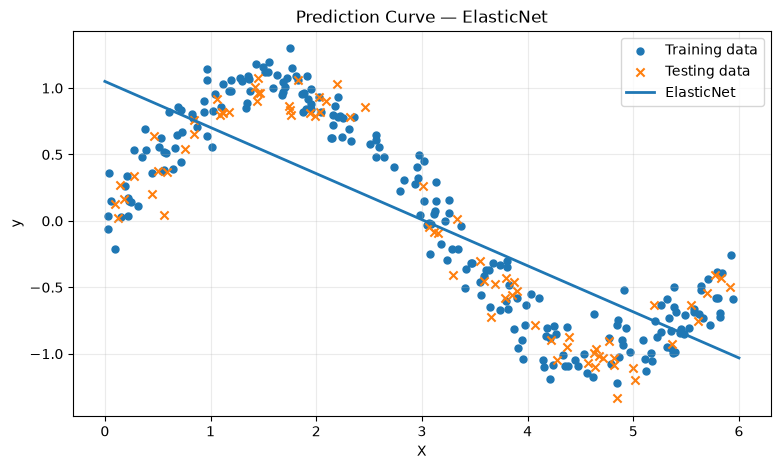

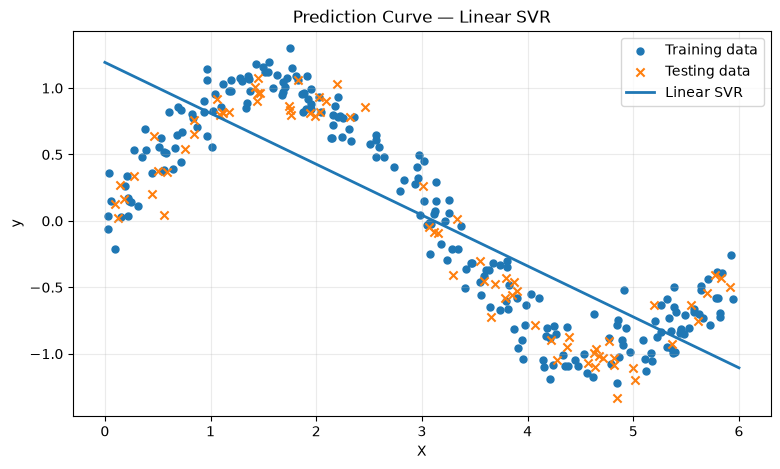

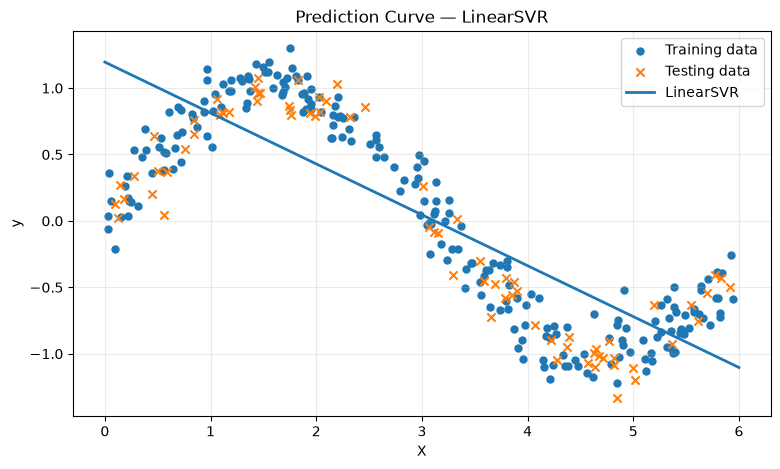

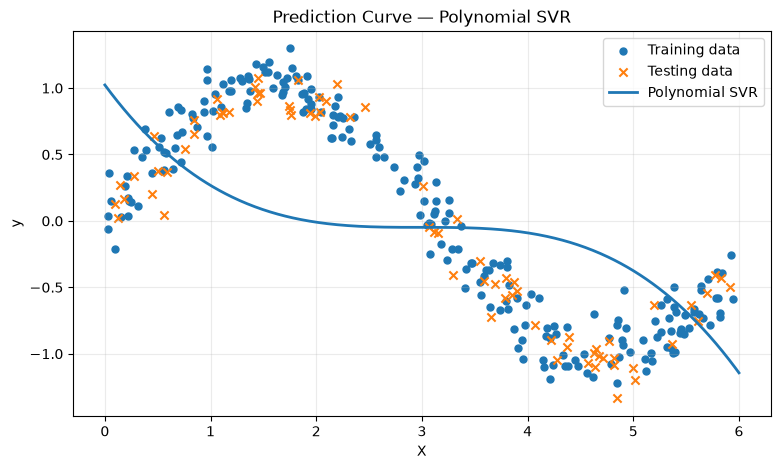

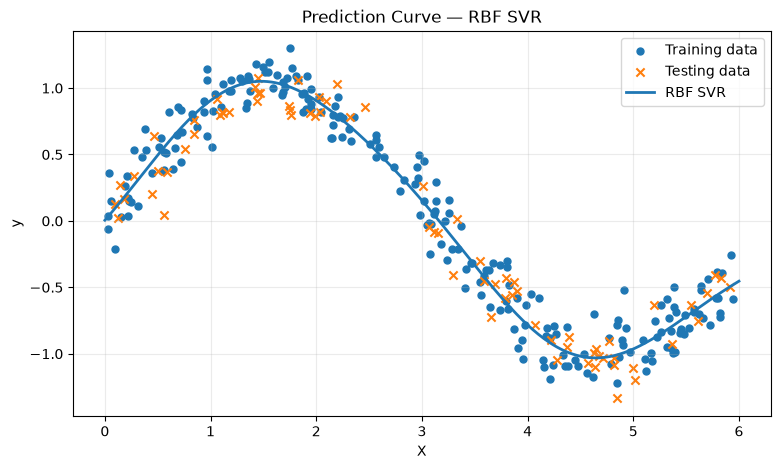

In [13]:
X_plot = np.linspace(0, 6, 500).reshape(-1, 1)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)

    plt.figure(figsize=(9, 5))
    plt.scatter(X_train, y_train, s=25, label="Training data")
    plt.scatter(X_test, y_test, s=35, marker="x", label="Testing data")
    plt.plot(X_plot, y_plot, linewidth=2, label=name)

    plt.title(f"Prediction Curve — {name}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

### Experiment with `eplison`

In [14]:
epsilon_values = [0.01, 0.1, 0.3, 0.7]

epsilon_results = []

for eps in epsilon_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10
        , gamma="scale", epsilon=eps))
    ])

    result = evaluate_regression_model(
        f"RBF SVR epsilon={eps}",
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    epsilon_results.append(result)

epsilon_df = pd.DataFrame(epsilon_results).sort_values(by="test_rmse")
print(epsilon_df)

                  model  train_rmse  test_mae  test_rmse   test_r2  \
1   RBF SVR epsilon=0.1    0.147953  0.120263   0.148263  0.962084   
0  RBF SVR epsilon=0.01    0.148520  0.122884   0.149036  0.961688   
2   RBF SVR epsilon=0.3    0.152122  0.118106   0.149852  0.961267   
3   RBF SVR epsilon=0.7    0.349457  0.298248   0.344150  0.795708   

   generalization_gap_rmse  training_time_sec  prediction_time_sec  
1                 0.000310           0.005976             0.001881  
0                 0.000515           0.005087             0.002693  
2                -0.002270           0.003624             0.000481  
3                -0.005307           0.002455             0.000414  


### Experiment with `c`

In [ ]:
c_values = [0.1, 1, 10, 100, 1000]
c_results = []
for c in c_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=c, 
        gamma="scale", epsilon=0.1))
    ])
    result = evaluate_regression_model(
        f"RBF SVR C={c}",
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    c_results.append(result)
c_df = pd.DataFrame(c_results).sort_values(by="test_rmse")
print(c_df)

            model  train_rmse  test_mae  test_rmse   test_r2  \
1     RBF SVR C=1    0.148497  0.113511   0.143117  0.964671   
0   RBF SVR C=0.1    0.155121  0.118206   0.147704  0.962369   
2    RBF SVR C=10    0.147953  0.120263   0.148263  0.962084   
3   RBF SVR C=100    0.147541  0.121409   0.149196  0.961606   
4  RBF SVR C=1000    0.147345  0.122056   0.150372  0.960998   

   generalization_gap_rmse  training_time_sec  prediction_time_sec  
1                -0.005381           0.002636             0.000861  
0                -0.007417           0.002887             0.000859  
2                 0.000310           0.005516             0.001409  
3                 0.001655           0.007890             0.001549  
4                 0.003026           0.021958             0.001461  


### Experiment with `gamma`

In [17]:
gamma_values = [0.01, 0.1, 1, 10, 100]
gamma_results = []
for gamma in gamma_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, 
        gamma=gamma, epsilon=0.1))
    ])
    result = evaluate_regression_model(
        f"RBF SVR gamma={gamma}",
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    gamma_results.append(result)
gamma_df = pd.DataFrame(gamma_results).sort_values(by="test_rmse")
print(gamma_df)

                model  train_rmse  test_mae  test_rmse   test_r2  \
2     RBF SVR gamma=1    0.147953  0.120263   0.148263  0.962084   
3    RBF SVR gamma=10    0.144506  0.120623   0.152515  0.959878   
1   RBF SVR gamma=0.1    0.162257  0.125436   0.159586  0.956071   
4   RBF SVR gamma=100    0.132946  0.143976   0.173218  0.948246   
0  RBF SVR gamma=0.01    0.425422  0.394563   0.447304  0.654887   

   generalization_gap_rmse  training_time_sec  prediction_time_sec  
2                 0.000310           0.004682             0.002485  
3                 0.008009           0.005663             0.001551  
1                -0.002671           0.004941             0.001905  
4                 0.040271           0.005404             0.001056  
0                 0.021882           0.004668             0.001864  


## 14. California Housing mini-comparison

### Creation of Datasets

In [18]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing(as_frame=True)
x=housing.data
y=housing.target

In [21]:
x_small = x.sample(n=3000, random_state=42)
y_small = y.loc[X_small.index]


### Train and test split

In [22]:
X_train,X_test,y_train,y_test=train_test_split(
     x_small,y_small,
     test_size=0.25,
     random_state=42
)

### Model Defining

In [24]:
models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, 
        l1_ratio=0.5, max_iter=10000))
    ]),

    "LinearSVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(C=1.0, epsilon=0.1, 
        max_iter=20000, random_state=42))
    ]),

    "RBF SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10, 
        gamma="scale", epsilon=0.1))
    ])
}

### Model Training and Evaluation

In [25]:
results = []

for name, model in models.items():
    result = evaluate_regression_model(
        name,
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )
    results.append(result)

housing_results_df = pd.DataFrame(results).sort_values(by="test_rmse")
print(housing_results_df)

        model  train_rmse  test_mae  test_rmse   test_r2  \
3     RBF SVR    0.507802  0.396776   0.562732  0.755649   
2   LinearSVR    0.803702  0.487492   0.673584  0.649898   
1  ElasticNet    0.731071  0.525839   0.693474  0.628917   
0       Ridge    0.731051  0.525689   0.693552  0.628834   

   generalization_gap_rmse  training_time_sec  prediction_time_sec  
3                 0.054930           0.365734             0.108346  
2                -0.130118           0.092659             0.002867  
1                -0.037597           0.008464             0.001969  
0                -0.037500           0.070641             0.002142  
